<a href="https://colab.research.google.com/github/vanivellee/portofolio/blob/main/Data%20sains.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# -*- coding: utf-8 -*-
"""
TAHAP 1 - LOAD & SELEKSI DATA
=============================
Membaca file JSON hasil scraping komentar TikTok, lalu mengambil kolom
yang relevan untuk analisis (membuang metadata yang tidak dipakai seperti
avatar, username, dsb).

Input  : KDMP.json
Output : tahap1_raw_selected.csv
"""

import json
import pandas as pd

INPUT_PATH = "KDMP.json"
OUTPUT_PATH = "tahap1_raw_selected.csv"

with open(INPUT_PATH, "r", encoding="utf-8") as f:
    raw_data = json.load(f)

df = pd.DataFrame(raw_data)
print(f"Total data mentah  : {len(df)} baris")
print(f"Kolom tersedia     : {list(df.columns)}")

# Ambil kolom yang relevan untuk analisis teks
df = df[["video_id", "comment_id", "username", "level", "comment", "create_time"]].copy()
df["comment"] = df["comment"].astype(str)

df.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")
print(f"Tahap 1 selesai -> disimpan ke {OUTPUT_PATH}")
print(df.head())

Total data mentah  : 220051 baris
Kolom tersedia     : ['video_id', 'comment_id', 'parent_comment_id', 'level', 'username', 'nickname', 'comment', 'create_time', 'avatar', 'total_reply', 'replies']
Tahap 1 selesai -> disimpan ke tahap1_raw_selected.csv
              video_id           comment_id                username level  \
0  7526458489577737488  7643302845156410130  jbm123jayabetonmandiri     0   
1  7526458489577737488  7643361778294866706         sahrulmustakimm     1   
2  7526458489577737488  7643368472755487495  jbm123jayabetonmandiri     1   
3  7526458489577737488  7643374126942798599         sahrulmustakimm     1   
4  7526458489577737488  7643368138729718536  jbm123jayabetonmandiri     1   

                                             comment          create_time  
0                     Beliau bilang untung nya 2 m ?  2026-05-24 10:58:57  
1                                        Makasih Mas  2026-05-24 14:47:33  
2  Gimana untung nya 2 m..barang yg di jual ajh g...  20

In [3]:
# -*- coding: utf-8 -*-
"""
TAHAP 2 - CLEANING DASAR (KOMENTAR KOSONG & DUPLIKAT)
======================================================
CATATAN PENTING: dataset ini berisi komentar dari 27 video TikTok yang
berbeda. Ini berarti dedup TIDAK BOLEH dilakukan asal hapus semua teks
yang sama secara global, karena reaksi pendek seperti "makasih", "😂😂😂",
atau "mantap" WAJAR muncul berkali-kali dari user yang berbeda-beda di
video yang berbeda-beda -- itu bukan spam, itu komentar independen.

Yang benar-benar indikasi spam/bot adalah komentar PANJANG yang identik
persis kata per kata. Pengecekan pada dataset ini menemukan pola seperti:
komentar panjang yang sama, diposting oleh 1 username yang sama di 7
video berbeda -- ini nyaris pasti bot/spam, bukan opini organik yang
kebetulan sama.

Maka aturan dedup yang dipakai di sini:
1. Komentar PENDEK (< AMBANG_KATA_SPAM kata) : duplikat TETAP DIPERTAHANKAN,
   karena wajar terjadi lintas video/user secara independen. (Komentar
   sependek ini nanti otomatis tersaring di tahap akhir jika tidak
   informatif setelah cleaning.)
2. Komentar PANJANG (>= AMBANG_KATA_SPAM kata) yang identik persis :
   dianggap indikasi spam/repost, hanya kemunculan pertama yang disimpan.

Input  : tahap1_raw_selected.csv
Output : tahap2_dedup.csv
"""

import pandas as pd

INPUT_PATH = "tahap1_raw_selected.csv"
OUTPUT_PATH = "tahap2_dedup.csv"

AMBANG_KATA_SPAM = 6  # komentar identik >= 6 kata dianggap indikasi spam/repost

df = pd.read_csv(INPUT_PATH, keep_default_na=False, na_filter=False)
print(f"Total data masuk        : {len(df)} baris")
print(f"Jumlah video unik       : {df['video_id'].nunique()}")

# 1. Buang komentar kosong / hanya spasi
df["comment"] = df["comment"].astype(str)
before = len(df)
df = df[df["comment"].str.strip() != ""]
print(f"Komentar kosong dibuang : {before - len(df)} baris")

# 2. Dedup sadar-panjang-komentar (lihat penjelasan di atas)
df["_jumlah_kata"] = df["comment"].str.split().str.len()

komentar_pendek = df[df["_jumlah_kata"] < AMBANG_KATA_SPAM]
komentar_panjang = df[df["_jumlah_kata"] >= AMBANG_KATA_SPAM]

before_panjang = len(komentar_panjang)
komentar_panjang = komentar_panjang.drop_duplicates(subset="comment")
print(f"Duplikat panjang (indikasi spam/bot) dibuang: {before_panjang - len(komentar_panjang)} baris")
print(f"Duplikat pendek dipertahankan (wajar lintas video/user): "
      f"{komentar_pendek.duplicated(subset='comment').sum()} baris")

df = pd.concat([komentar_pendek, komentar_panjang]).sort_index()
df = df.drop(columns="_jumlah_kata").reset_index(drop=True)

print(f"Total data setelah tahap 2 : {len(df)} baris")
df.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")
print(f"Tahap 2 selesai -> disimpan ke {OUTPUT_PATH}")

Total data masuk        : 220051 baris
Jumlah video unik       : 27
Komentar kosong dibuang : 304 baris
Duplikat panjang (indikasi spam/bot) dibuang: 51423 baris
Duplikat pendek dipertahankan (wajar lintas video/user): 50498 baris
Total data setelah tahap 2 : 168324 baris
Tahap 2 selesai -> disimpan ke tahap2_dedup.csv


In [4]:
# -*- coding: utf-8 -*-
"""
TAHAP 3 - CASE FOLDING
======================
Menyeragamkan semua huruf menjadi huruf kecil, agar kata yang sama tapi
beda kapitalisasi (mis. "Koperasi", "KOPERASI", "koperasi") dihitung
sebagai kata yang identik oleh komputer.

Input  : tahap2_dedup.csv
Output : tahap3_case_folding.csv
"""

import pandas as pd

INPUT_PATH = "tahap2_dedup.csv"
OUTPUT_PATH = "tahap3_case_folding.csv"

df = pd.read_csv(INPUT_PATH, keep_default_na=False, na_filter=False)
df["comment"] = df["comment"].astype(str)

df["text_step"] = df["comment"].str.lower()

df.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")
print(f"Tahap 3 selesai -> disimpan ke {OUTPUT_PATH}")
print(df[["comment", "text_step"]].head())

Tahap 3 selesai -> disimpan ke tahap3_case_folding.csv
                                             comment  \
0                     Beliau bilang untung nya 2 m ?   
1                                        Makasih Mas   
2  Gimana untung nya 2 m..barang yg di jual ajh g...   
3         [Sticker] dibilang Makasih Mas udah 2M itu   
4                                                😳😳😳   

                                           text_step  
0                     beliau bilang untung nya 2 m ?  
1                                        makasih mas  
2  gimana untung nya 2 m..barang yg di jual ajh g...  
3         [sticker] dibilang makasih mas udah 2m itu  
4                                                😳😳😳  


In [5]:
# -*- coding: utf-8 -*-
"""
TAHAP 4 - CLEANING SIMBOL (URL, MENTION, HASHTAG, EMOJI, ANGKA, TANDA BACA)
============================================================================
Komentar TikTok banyak mengandung elemen non-linguistik yang perlu dibuang
agar tidak mengganggu proses selanjutnya:
- URL (link)
- mention (@username)
- hashtag (#tagar)
- emoji / simbol unicode
- angka
- tanda baca

Input  : tahap3_case_folding.csv
Output : tahap4_cleaning_simbol.csv
"""

import re
import string
import pandas as pd

INPUT_PATH = "tahap3_case_folding.csv"
OUTPUT_PATH = "tahap4_cleaning_simbol.csv"

EMOJI_PATTERN = re.compile(
    "["
    "\U0001F600-\U0001F64F"  # emoticon
    "\U0001F300-\U0001F5FF"  # simbol & piktograf
    "\U0001F680-\U0001F6FF"  # transportasi
    "\U0001F1E0-\U0001F1FF"  # bendera
    "\U00002700-\U000027BF"
    "\U0001F900-\U0001F9FF"
    "\U00002600-\U000026FF"
    "\U0001FA70-\U0001FAFF"
    "]+",
    flags=re.UNICODE,
)


def remove_url_mention_hashtag(text: str) -> str:
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#\w+", " ", text)
    return text


def remove_emoji(text: str) -> str:
    return EMOJI_PATTERN.sub(" ", text)


def remove_number_punctuation(text: str) -> str:
    text = re.sub(r"\d+", " ", text)
    text = text.translate(str.maketrans(string.punctuation, " " * len(string.punctuation)))
    return text


def remove_extra_whitespace(text: str) -> str:
    return re.sub(r"\s+", " ", text).strip()


def clean_symbols(text: str) -> str:
    text = remove_url_mention_hashtag(text)
    text = remove_emoji(text)
    text = remove_number_punctuation(text)
    text = remove_extra_whitespace(text)
    return text


df = pd.read_csv(INPUT_PATH, keep_default_na=False, na_filter=False)
df["text_step"] = df["text_step"].astype(str)

df["text_step"] = df["text_step"].apply(clean_symbols)

# buang baris yang jadi kosong total setelah simbol dibuang
before = len(df)
df = df[df["text_step"].str.strip() != ""].reset_index(drop=True)
print(f"Baris kosong setelah cleaning simbol dibuang: {before - len(df)}")

df.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")
print(f"Tahap 4 selesai -> disimpan ke {OUTPUT_PATH}")
print(df[["comment", "text_step"]].head())

Baris kosong setelah cleaning simbol dibuang: 8612
Tahap 4 selesai -> disimpan ke tahap4_cleaning_simbol.csv
                                             comment  \
0                     Beliau bilang untung nya 2 m ?   
1                                        Makasih Mas   
2  Gimana untung nya 2 m..barang yg di jual ajh g...   
3         [Sticker] dibilang Makasih Mas udah 2M itu   
4  Kalo niat membantu UMKM, harusnya koprasi mera...   

                                           text_step  
0                         beliau bilang untung nya m  
1                                        makasih mas  
2  gimana untung nya m barang yg di jual ajh ga a...  
3            sticker dibilang makasih mas udah m itu  
4  kalo niat membantu umkm harusnya koprasi merah...  


In [6]:
# -*- coding: utf-8 -*-
"""
TAHAP 5 - NORMALISASI ELONGASI (HURUF BERULANG)
================================================
Komentar media sosial sering menuliskan huruf berulang untuk penekanan
emosi, misal "bagusssss" -> "bagus", "wkwkwkwk" -> "wkwk".
Tahap ini membatasi pengulangan huruf berturut-turut maksimal 2 huruf,
sehingga variasi penulisan yang sama akan menjadi satu bentuk yang lebih
konsisten sebelum dinormalisasi ke kata baku pada tahap berikutnya.

Input  : tahap4_cleaning_simbol.csv
Output : tahap5_elongasi.csv
"""

import re
import pandas as pd

INPUT_PATH = "tahap4_cleaning_simbol.csv"
OUTPUT_PATH = "tahap5_elongasi.csv"


def normalize_elongation(text: str) -> str:
    """Contoh: 'bagusssss' -> 'baguss' (maks 2 huruf berulang berturut-turut)."""
    return re.sub(r"(.)\1{2,}", r"\1\1", text)


df = pd.read_csv(INPUT_PATH, keep_default_na=False, na_filter=False)
df["text_step"] = df["text_step"].astype(str)

df["text_step"] = df["text_step"].apply(normalize_elongation)

df.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")
print(f"Tahap 5 selesai -> disimpan ke {OUTPUT_PATH}")
print(df[["comment", "text_step"]].head())

Tahap 5 selesai -> disimpan ke tahap5_elongasi.csv
                                             comment  \
0                     Beliau bilang untung nya 2 m ?   
1                                        Makasih Mas   
2  Gimana untung nya 2 m..barang yg di jual ajh g...   
3         [Sticker] dibilang Makasih Mas udah 2M itu   
4  Kalo niat membantu UMKM, harusnya koprasi mera...   

                                           text_step  
0                         beliau bilang untung nya m  
1                                        makasih mas  
2  gimana untung nya m barang yg di jual ajh ga a...  
3            sticker dibilang makasih mas udah m itu  
4  kalo niat membantu umkm harusnya koprasi merah...  


In [7]:
# -*- coding: utf-8 -*-
"""
TAHAP 6 - NORMALISASI KATA TIDAK BAKU (SLANG / ALAY -> BAKU)
==============================================================
Ini adalah tahap inti yang menjawab Rumusan Masalah #1: mengubah kata-kata
tidak baku (bahasa gaul/alay khas media sosial Indonesia) menjadi bentuk
baku, memakai kamus referensi ilmiah + kamus tambahan khusus domain KDMP.

Referensi kamus alay:
- Salsabila, N. A., Winatmoko, Y. A., Septiandri, A. A., & Jamal, A. (2018).
  "Colloquial Indonesian Lexicon". 2018 International Conference on Asian
  Language Processing (IALP), Bandung, Indonesia: IEEE, pp. 226-229.
  DOI: 10.1109/IALP.2018.8629151
  Dataset: https://github.com/nasalsabila/kamus-alay
  (berisi ±4.300 pasangan kata slang -> baku setelah proses deduplikasi)
- Kamus tambahan manual (kamus_alay_tambahan_kdmp.csv) berisi istilah yang
  spesifik pada konteks KDMP (mis. "kdmp", "duitnya", "ruginya") dan
  singkatan umum yang belum tercakup kamus referensi di atas.

Kedua kamus sudah digabung sebelumnya menjadi satu file: kamus_alay.csv
(entri dari kamus tambahan KDMP diprioritaskan bila ada kata yang sama).

Input  : tahap5_elongasi.csv
Kamus  : kamus_alay.csv
Output : tahap6_normalisasi_slang.csv
"""

import re
import pandas as pd

INPUT_PATH = "tahap5_elongasi.csv"
KAMUS_PATH = "kamus_alay.csv"
OUTPUT_PATH = "tahap6_normalisasi_slang.csv"

# --- Load kamus alay sebagai dictionary lookup ---
kamus_df = pd.read_csv(KAMUS_PATH, keep_default_na=False, na_filter=False)
SLANG_DICT = dict(zip(kamus_df["slang"], kamus_df["formal"]))
print(f"Total entri kamus alay yang dimuat: {len(SLANG_DICT)}")


def remove_extra_whitespace(text: str) -> str:
    return re.sub(r"\s+", " ", text).strip()


def normalize_slang(text: str) -> str:
    """Mengganti tiap kata jika ditemukan padanannya di kamus alay."""
    words = text.split()
    normalized = [SLANG_DICT.get(w, w) for w in words]
    return remove_extra_whitespace(" ".join(normalized))


df = pd.read_csv(INPUT_PATH, keep_default_na=False, na_filter=False)
df["text_step"] = df["text_step"].astype(str)

df["text_step"] = df["text_step"].apply(normalize_slang)

# buang baris yang jadi kosong setelah normalisasi (kata slang tanpa makna, mis. "wkwk")
before = len(df)
df = df[df["text_step"].str.strip() != ""].reset_index(drop=True)
print(f"Baris kosong setelah normalisasi slang dibuang: {before - len(df)}")

df.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")
print(f"Tahap 6 selesai -> disimpan ke {OUTPUT_PATH}")
print(df[["comment", "text_step"]].head())

Total entri kamus alay yang dimuat: 4373
Baris kosong setelah normalisasi slang dibuang: 186
Tahap 6 selesai -> disimpan ke tahap6_normalisasi_slang.csv
                                             comment  \
0                     Beliau bilang untung nya 2 m ?   
1                                        Makasih Mas   
2  Gimana untung nya 2 m..barang yg di jual ajh g...   
3         [Sticker] dibilang Makasih Mas udah 2M itu   
4  Kalo niat membantu UMKM, harusnya koprasi mera...   

                                           text_step  
0                      beliau bilang untung nya sama  
1                                   terima kasih mas  
2  bagaimana untung nya sama barang yang di jual ...  
3   sticker dibilang terima kasih mas sudah sama itu  
4  kalau niat membantu usaha mikro kecil menengah...  


In [8]:
# -*- coding: utf-8 -*-
"""
TAHAP 7 - TOKENISASI
====================
Memecah kalimat bersih menjadi daftar kata (token), sebagai satuan dasar
sebelum stopword removal dan stemming. Tokenisasi di sini menggunakan
pemisah spasi karena teks sudah dibersihkan dari tanda baca pada tahap 4.

Input  : tahap6_normalisasi_slang.csv
Output : tahap7_tokenisasi.csv (kolom 'tokens' berisi list token dalam bentuk string)
"""

import ast
import pandas as pd

INPUT_PATH = "tahap6_normalisasi_slang.csv"
OUTPUT_PATH = "tahap7_tokenisasi.csv"

df = pd.read_csv(INPUT_PATH, keep_default_na=False, na_filter=False)
df["text_step"] = df["text_step"].astype(str)

df["tokens"] = df["text_step"].apply(lambda t: t.split())

# simpan sebagai string representasi list agar aman dibaca ulang lewat CSV
df["tokens"] = df["tokens"].apply(lambda toks: str(toks))

df.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")
print(f"Tahap 7 selesai -> disimpan ke {OUTPUT_PATH}")
print(df[["text_step", "tokens"]].head())

# contoh cara membaca ulang kolom tokens sebagai list python:
# df["tokens"] = df["tokens"].apply(ast.literal_eval)

Tahap 7 selesai -> disimpan ke tahap7_tokenisasi.csv
                                           text_step  \
0                      beliau bilang untung nya sama   
1                                   terima kasih mas   
2  bagaimana untung nya sama barang yang di jual ...   
3   sticker dibilang terima kasih mas sudah sama itu   
4  kalau niat membantu usaha mikro kecil menengah...   

                                              tokens  
0      ['beliau', 'bilang', 'untung', 'nya', 'sama']  
1                         ['terima', 'kasih', 'mas']  
2  ['bagaimana', 'untung', 'nya', 'sama', 'barang...  
3  ['sticker', 'dibilang', 'terima', 'kasih', 'ma...  
4  ['kalau', 'niat', 'membantu', 'usaha', 'mikro'...  


In [9]:
# -*- coding: utf-8 -*-
"""
TAHAP 8 - STOPWORD REMOVAL
==========================
Membuang kata-kata umum yang sering muncul namun tidak membawa makna
penting untuk topic modeling maupun sentimen (mis. "yang", "di", "dan").
Menggunakan daftar stopword bawaan Sastrawi ditambah daftar tambahan
khusus untuk sisa kata non-formal yang masih lolos dari normalisasi
tahap sebelumnya (mis. "sih", "dong", "banget").

Input  : tahap7_tokenisasi.csv
Output : tahap8_stopword_removal.csv
"""

# Install Sastrawi if not already installed
!pip install Sastrawi

import ast
import pandas as pd
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

INPUT_PATH = "tahap7_tokenisasi.csv"
OUTPUT_PATH = "tahap8_stopword_removal.csv"

EXTRA_STOPWORDS = {
    "nya", "yg", "ya", "sih", "deh", "dong", "kok", "aja", "saja", "loh",
    "lah", "kan", "gitu", "gini", "banget", "amp", "min",
}

stopword_factory = StopWordRemoverFactory()
base_stopwords = set(stopword_factory.get_stop_words())
ALL_STOPWORDS = base_stopwords | EXTRA_STOPWORDS
print(f"Total stopword (bawaan Sastrawi + tambahan): {len(ALL_STOPWORDS)}")


def remove_stopwords(tokens: list) -> list:
    return [t for t in tokens if t not in ALL_STOPWORDS and len(t) > 1]


df = pd.read_csv(INPUT_PATH, keep_default_na=False, na_filter=False, low_memory=False)
df["tokens"] = df["tokens"].apply(ast.literal_eval)

df["tokens"] = df["tokens"].apply(remove_stopwords)

# buang baris yang token-nya jadi kosong
before = len(df)
df = df[df["tokens"].apply(len) > 0].reset_index(drop=True)
print(f"Baris kosong setelah stopword removal dibuang: {before - len(df)}")

df["tokens"] = df["tokens"].apply(lambda toks: str(toks))
df.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")
print(f"Tahap 8 selesai -> disimpan ke {OUTPUT_PATH}")
print(df[["text_step", "tokens"]].head())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 8.8 MB/s eta 0:00:00
Total stopword (bawaan Sastrawi + tambahan): 138
Baris kosong setelah stopword removal dibuang: 784
Tahap 8 selesai -> disimpan ke tahap8_stopword_removal.csv
                                           text_step  \
0                      beliau bilang untung nya sama   
1                                   terima kasih mas   
2  bagaimana untung nya sama barang yang di jual ...   
3   sticker dibilang terima kasih mas sudah sama itu   
4  kalau niat membantu usaha mikro kecil menengah...   

                                              tokens  
0             ['beliau', 'bilang', 'untung', 'sama']  
1                         ['terima', 'kasih', 'mas']  
2  ['bagaimana', 'untung', 'sama', 'barang', 'jua...  
3  ['sticker', 'dibilang', 'terima', 'kasih', 'ma...  
4  ['kalau', 'niat', 'membantu', 'usaha', 'mikro'...  


In [10]:
# -*- coding: utf-8 -*-
"""
TAHAP 9 - STEMMING
==================
Mengubah kata berimbuhan menjadi kata dasarnya memakai algoritma Sastrawi
(mis. "mengeluhkan" -> "keluh", "dibantu" -> "bantu"), agar variasi
bentukan kata dari akar yang sama dihitung sebagai satu term yang identik
oleh model topic modeling maupun lexicon-based sentiment.

Menggunakan cache per-kata karena Sastrawi relatif berat jika dipanggil
berulang untuk kata yang sama pada dataset besar (~200 ribuan baris).

Input  : tahap8_stopword_removal.csv
Output : tahap9_stemming.csv
"""

import ast
import os
import time
import multiprocessing as mp
import pandas as pd
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

INPUT_PATH = "tahap8_stopword_removal.csv"
OUTPUT_PATH = "tahap9_stemming.csv"

# CATATAN PERFORMA: stemming kata BARU (belum pernah ditemui) di Sastrawi
# relatif berat (proses trial-and-error pelucutan imbuhan). Pada dataset
# besar seperti ini (~220 ribu baris), jumlah kata UNIK bisa puluhan ribu,
# sehingga stemming satu-per-satu secara berurutan bisa memakan waktu
# sangat lama. Trik di sini:
#   1. Kumpulkan dulu SEMUA kata unik di seluruh dataset (bukan per baris).
#   2. Stem kata unik itu SEKALI SAJA, disebar ke beberapa proses CPU
#      sekaligus (multiprocessing) agar memanfaatkan semua core yang ada.
#   3. Hasilnya dipakai sebagai kamus lookup untuk mengganti token di
#      setiap baris (tinggal dict lookup, sangat cepat, tanpa panggil
#      stemmer lagi).
# Dengan begini python hanya men-stem tiap kata unik SATU KALI walau kata
# itu muncul ribuan kali di 220 ribu komentar.

_worker_stemmer = None


def _init_worker():
    """Dipanggil sekali per proses worker agar stemmer tidak dibuat ulang
    setiap kata (overhead pembuatan objek stemmer cukup mahal)."""
    global _worker_stemmer
    _worker_stemmer = StemmerFactory().create_stemmer()


def _stem_one(word: str) -> str:
    return _worker_stemmer.stem(word)


def main():
    df = pd.read_csv(INPUT_PATH, keep_default_na=False, na_filter=False)
    df["tokens"] = df["tokens"].apply(ast.literal_eval)

    # 1. Kumpulkan semua kata unik di seluruh dataset
    unique_words = sorted({t for tokens in df["tokens"] for t in tokens})
    print(f"Total baris          : {len(df)}")
    print(f"Total kata unik      : {len(unique_words)} (ini yang akan di-stem, bukan per baris)")

    n_workers = max(1, os.cpu_count() or 1)
    print(f"Menjalankan stemming paralel dengan {n_workers} proses, mohon tunggu...")

    t0 = time.time()
    # chunksize besar mengurangi overhead komunikasi antar proses
    chunksize = max(1, len(unique_words) // (n_workers * 8) or 1)
    with mp.Pool(processes=n_workers, initializer=_init_worker) as pool:
        stemmed_results = pool.map(_stem_one, unique_words, chunksize=chunksize)
    print(f"Stemming kata unik selesai dalam {time.time() - t0:.1f} detik")

    word_to_stem = dict(zip(unique_words, stemmed_results))

    # 2. Terapkan hasil stem ke tiap baris via dict lookup (cepat)
    def apply_stem(tokens):
        return [word_to_stem[t] for t in tokens if len(word_to_stem[t]) > 1]

    df["tokens"] = df["tokens"].apply(apply_stem)

    df["tokens"] = df["tokens"].apply(lambda toks: str(toks))
    df.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")
    print(f"Tahap 9 selesai -> disimpan ke {OUTPUT_PATH}")
    print(df[["text_step", "tokens"]].head())


if __name__ == "__main__":
    # wajib dibungkus __main__ karena memakai multiprocessing di Windows/macOS
    main()

/tmp/ipykernel_1990/1517283882.py:56: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(INPUT_PATH, keep_default_na=False, na_filter=False)


Total baris          : 158742
Total kata unik      : 44148 (ini yang akan di-stem, bukan per baris)
Menjalankan stemming paralel dengan 2 proses, mohon tunggu...
Stemming kata unik selesai dalam 4845.0 detik
Tahap 9 selesai -> disimpan ke tahap9_stemming.csv
                                           text_step  \
0                      beliau bilang untung nya sama   
1                                   terima kasih mas   
2  bagaimana untung nya sama barang yang di jual ...   
3   sticker dibilang terima kasih mas sudah sama itu   
4  kalau niat membantu usaha mikro kecil menengah...   

                                              tokens  
0             ['beliau', 'bilang', 'untung', 'sama']  
1                         ['terima', 'kasih', 'mas']  
2  ['bagaimana', 'untung', 'sama', 'barang', 'jua...  
3  ['sticker', 'bilang', 'terima', 'kasih', 'mas'...  
4  ['kalau', 'niat', 'bantu', 'usaha', 'mikro', '...  


In [11]:
# -*- coding: utf-8 -*-
"""
TAHAP 10 - FILTERING AKHIR & PENYIMPANAN HASIL
================================================
Tahap penutup pipeline preprocessing:
1. Menggabungkan token hasil stemming menjadi teks bersih final
   ('final_text') yang siap dipakai untuk LDA topic modeling dan
   lexicon-based sentiment analysis (BUKAN dengan TF-IDF).
2. Membuang baris yang hasil akhirnya kosong atau terlalu pendek
   (minimal 2 kata) karena tidak cukup informatif untuk dianalisis.
3. Menyimpan hasil akhir sebagai dataset bersih untuk tahap analisis
   berikutnya.

Input  : tahap9_stemming.csv
Output : KDMP_clean_final.csv
"""

import ast
import pandas as pd

INPUT_PATH = "tahap9_stemming.csv"
OUTPUT_PATH = "KDMP_clean_final.csv"

df = pd.read_csv(INPUT_PATH, keep_default_na=False, na_filter=False)
df["tokens"] = df["tokens"].apply(ast.literal_eval)

df["final_text"] = df["tokens"].apply(lambda toks: " ".join(toks))

before = len(df)
df = df[df["final_text"].str.split().str.len() >= 2].reset_index(drop=True)
print(f"Baris dibuang karena hasil akhir terlalu pendek/kosong: {before - len(df)}")

print(f"Total data akhir siap dianalisis: {len(df)} baris")

final_df = df[["video_id", "comment_id", "level", "create_time", "comment", "final_text"]]
final_df.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")
print(f"Tahap 10 selesai -> disimpan ke {OUTPUT_PATH}")

print("\nContoh perbandingan sebelum dan sesudah preprocessing:")
for i in range(min(5, len(final_df))):
    print(f"\nAsli   : {final_df['comment'].iloc[i]}")
    print(f"Bersih : {final_df['final_text'].iloc[i]}")

/tmp/ipykernel_1990/512383466.py:24: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(INPUT_PATH, keep_default_na=False, na_filter=False)


Baris dibuang karena hasil akhir terlalu pendek/kosong: 19925
Total data akhir siap dianalisis: 138817 baris
Tahap 10 selesai -> disimpan ke KDMP_clean_final.csv

Contoh perbandingan sebelum dan sesudah preprocessing:

Asli   : Beliau bilang untung nya 2 m ?
Bersih : beliau bilang untung sama

Asli   : Makasih Mas
Bersih : terima kasih mas

Asli   : Gimana untung nya 2 m..barang yg di jual ajh ga ada 1 m 😁
Bersih : bagaimana untung sama barang jual sama

Asli   : [Sticker] dibilang Makasih Mas udah 2M itu
Bersih : sticker bilang terima kasih mas sama

Asli   : Kalo niat membantu UMKM, harusnya koprasi merah putih dibuka dalam bentuk warehouse (gudang), bukan bentuk toko, jadi yang belanja cuma UMKM yang memiliki usaha toko kelontong supaya dapat harga lebih murah dan konsumen toko kelontong dapat harga yang stabil, kalok di buka dalam bentuk toko, dimana semua masyarakat umum bisa membeli dengan harga lebih murah, maka orang2 yang biasa belanja di warung kelontong lebih memilih belanja

RINGKASAN DATASET SETELAH PREPROCESSING
Total komentar (baris)     : 138817
Total video unik           : 27
Rentang waktu komentar     : 2025-07-13 14:07:27 s.d. 2026-05-27 06:45:05

Distribusi level komentar:
  Level             : 30423 (21.9%)
  Level 0           : 81466 (58.7%)
  Level 1           : 26928 (19.4%)

Jumlah komentar per video (10 teratas):
video_id
7641276206687554823    16834
7641470196108004626    13093
7641041003423501576    12744
7643478603576954132    11294
7640891074545749266     8589
7637357539209841941     8222
7641183642437586196     8099
7640835929623579912     7342
7640152776986660103     6400
7641781303423061255     4569
Name: count, dtype: int64

Grafik disimpan: grafik01_distribusi_komentar_per_video.png


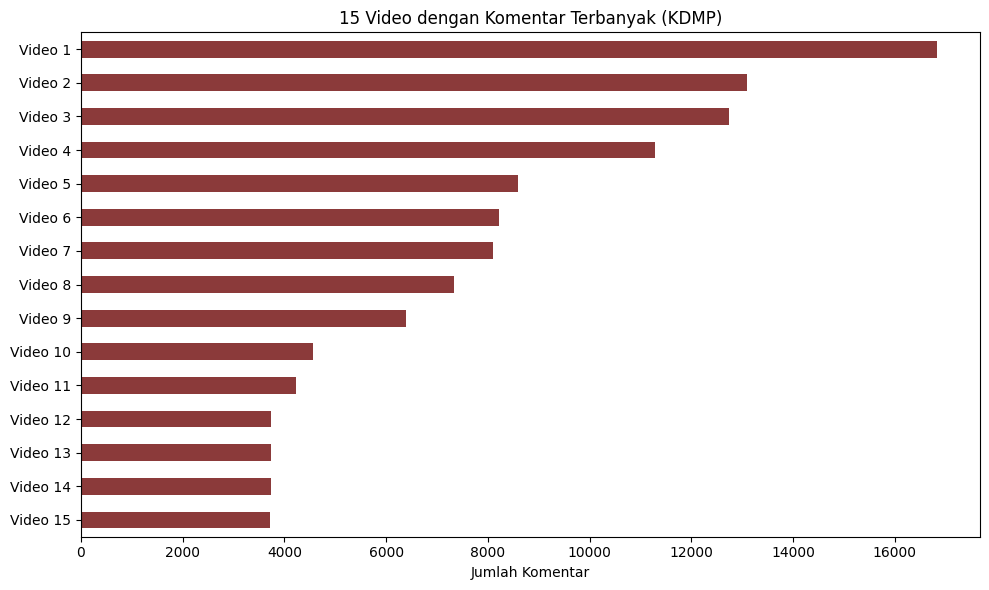

In [12]:
# -*- coding: utf-8 -*-
"""
TAHAP 11 - STATISTIK DASAR (DATA EXPLORATION)
==============================================
Tahap awal eksplorasi data (EDA) setelah preprocessing selesai. Tujuannya
untuk mengenali karakteristik dataset sebelum masuk ke topic modeling
(LDA) dan sentiment analysis, meliputi:
1. Ringkasan jumlah data (baris, video, level komentar)
2. Distribusi komentar per video (video mana yang paling ramai dibahas)
3. Distribusi level komentar (komentar utama vs balasan/reply)

Input  : KDMP_clean_final.csv
Output : (dicetak ke konsol) + grafik01_distribusi_komentar_per_video.png
"""

import pandas as pd
import matplotlib.pyplot as plt

INPUT_PATH = "KDMP_clean_final.csv"

df = pd.read_csv(INPUT_PATH, keep_default_na=False, na_filter=False)

print("=" * 60)
print("RINGKASAN DATASET SETELAH PREPROCESSING")
print("=" * 60)
print(f"Total komentar (baris)     : {len(df)}")
print(f"Total video unik           : {df['video_id'].nunique()}")
print(f"Rentang waktu komentar     : {df['create_time'].min()} s.d. {df['create_time'].max()}")

print("\nDistribusi level komentar:")
level_map = {0: "Komentar utama", 1: "Balasan (reply)"}
level_counts = df["level"].value_counts().sort_index()
for lvl, cnt in level_counts.items():
    label = level_map.get(lvl, f"Level {lvl}")
    print(f"  {label:<18}: {cnt} ({cnt/len(df)*100:.1f}%)")

print("\nJumlah komentar per video (10 teratas):")
video_counts = df["video_id"].value_counts().head(10)
print(video_counts)

# --- Grafik: distribusi komentar per video ---
plt.figure(figsize=(10, 6))
top_videos = df["video_id"].value_counts().head(15)
top_videos.index = [f"Video {i+1}" for i in range(len(top_videos))]
top_videos.plot(kind="barh", color="#8B3A3A")
plt.gca().invert_yaxis()
plt.xlabel("Jumlah Komentar")
plt.title("15 Video dengan Komentar Terbanyak (KDMP)")
plt.tight_layout()
plt.savefig("grafik01_distribusi_komentar_per_video.png", dpi=150)
print("\nGrafik disimpan: grafik01_distribusi_komentar_per_video.png")

Statistik panjang komentar ASLI (jumlah kata):
count    138817.000000
mean          8.699259
std           9.302999
min           1.000000
25%           4.000000
50%           5.000000
75%          10.000000
max         310.000000
Name: panjang_asli, dtype: float64

Statistik panjang komentar BERSIH setelah preprocessing (jumlah kata):
count    138817.000000
mean          6.357341
std           6.606059
min           2.000000
25%           3.000000
50%           4.000000
75%           7.000000
max         208.000000
Name: panjang_bersih, dtype: float64

Grafik disimpan: grafik02_distribusi_panjang_komentar.png


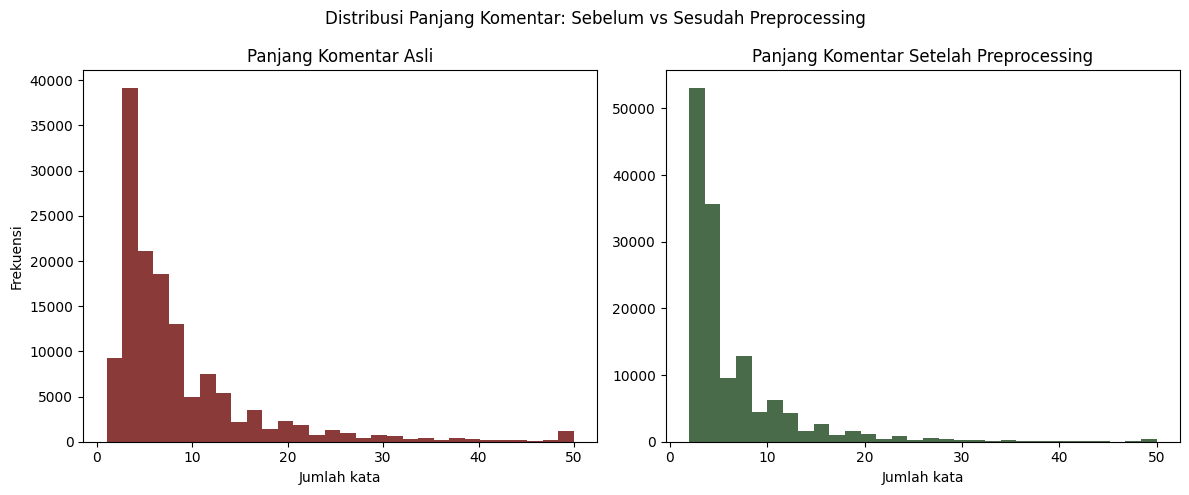

In [13]:
# -*- coding: utf-8 -*-
"""
TAHAP 12 - DISTRIBUSI PANJANG KOMENTAR
========================================
Melihat sebaran jumlah kata per komentar, sebelum (teks asli) dan sesudah
preprocessing (final_text). Berguna untuk:
- Mengecek apakah preprocessing memangkas teks secara wajar (tidak
  berlebihan sampai menghilangkan makna)
- Menentukan apakah perlu ambang batas tambahan untuk topic modeling
  (komentar yang terlalu pendek biasanya kurang informatif untuk LDA)

Input  : KDMP_clean_final.csv
Output : (dicetak ke konsol) + grafik02_distribusi_panjang_komentar.png
"""

import pandas as pd
import matplotlib.pyplot as plt

INPUT_PATH = "KDMP_clean_final.csv"

df = pd.read_csv(INPUT_PATH, keep_default_na=False, na_filter=False)

df["panjang_asli"] = df["comment"].str.split().str.len()
df["panjang_bersih"] = df["final_text"].str.split().str.len()

print("Statistik panjang komentar ASLI (jumlah kata):")
print(df["panjang_asli"].describe())

print("\nStatistik panjang komentar BERSIH setelah preprocessing (jumlah kata):")
print(df["panjang_bersih"].describe())

# --- Grafik: histogram perbandingan sebelum vs sesudah ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df["panjang_asli"].clip(upper=50), bins=30, color="#8B3A3A")
axes[0].set_title("Panjang Komentar Asli")
axes[0].set_xlabel("Jumlah kata")
axes[0].set_ylabel("Frekuensi")

axes[1].hist(df["panjang_bersih"].clip(upper=50), bins=30, color="#4A6B4A")
axes[1].set_title("Panjang Komentar Setelah Preprocessing")
axes[1].set_xlabel("Jumlah kata")

plt.suptitle("Distribusi Panjang Komentar: Sebelum vs Sesudah Preprocessing")
plt.tight_layout()
plt.savefig("grafik02_distribusi_panjang_komentar.png", dpi=150)
print("\nGrafik disimpan: grafik02_distribusi_panjang_komentar.png")

Total kata (token) keseluruhan : 882507
Total kata unik                : 32390

30 kata paling sering muncul:
  kalau               : 11297
  sama                : 9959
  kayak               : 9429
  koperasi            : 9210
  mau                 : 8606
  apa                 : 8280
  harga               : 7631
  warung              : 7622
  desa                : 7023
  jadi                : 6981
  kecil               : 6442
  usaha               : 6418
  kak                 : 6384
  beli                : 6227
  indomaret           : 6118
  tutup               : 5836
  jual                : 5784
  banyak              : 5597
  rakyat              : 5472
  kopdes              : 5449
  barang              : 5427
  toko                : 5290
  alfa                : 5167
  lebih               : 5012
  merah               : 5000
  saing               : 4831
  putih               : 4781
  buka                : 4742
  pak                 : 4687
  alfamart            : 4550

Grafik disimpan: g

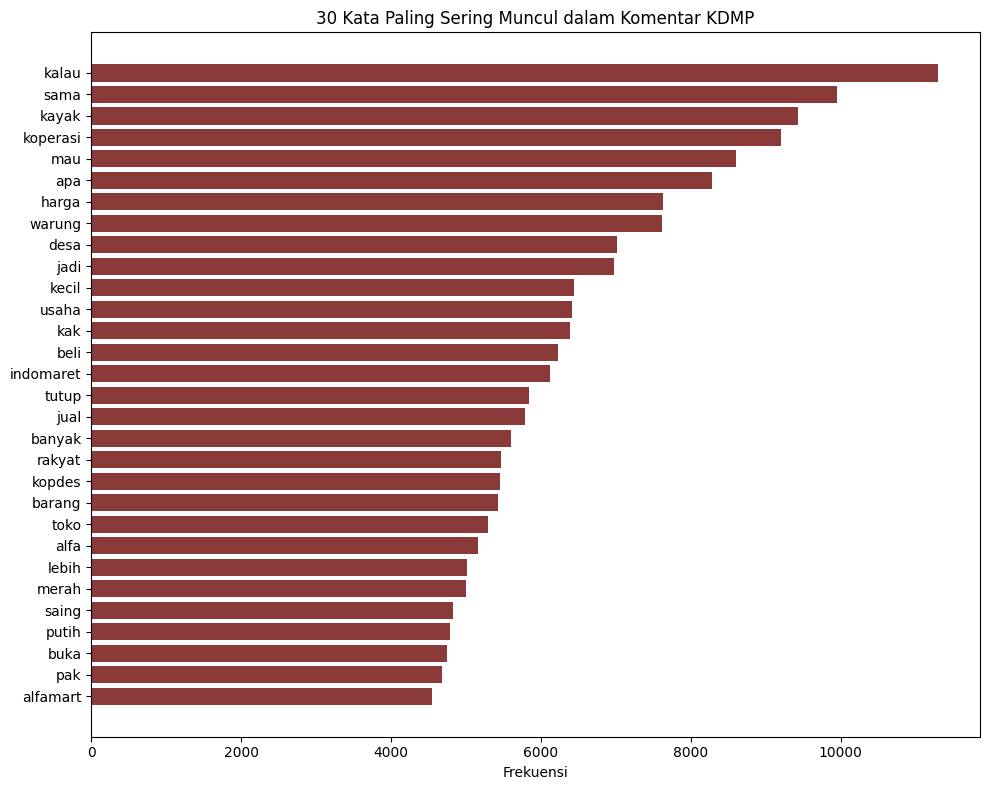

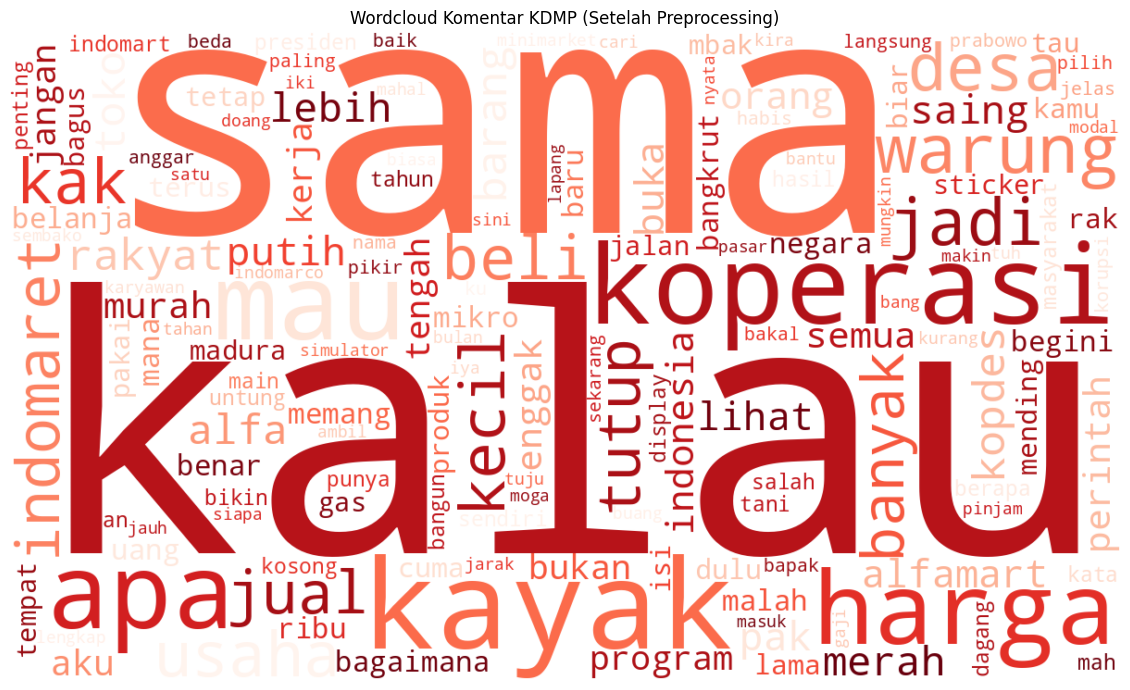

In [14]:
# -*- coding: utf-8 -*-
"""
TAHAP 13 - FREKUENSI KATA & WORDCLOUD
========================================
Melihat kata-kata apa yang paling sering muncul di komentar setelah
preprocessing. Ini adalah eksplorasi awal untuk menjawab Rumusan
Masalah #2 (topik/isu utama yang dikeluhkan/diapresiasi netizen)
sebelum masuk ke pemodelan topik (LDA) yang lebih formal.

Input  : KDMP_clean_final.csv
Output : (dicetak ke konsol) + grafik03_top30_kata.png + grafik04_wordcloud.png
"""

from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

INPUT_PATH = "KDMP_clean_final.csv"

df = pd.read_csv(INPUT_PATH, keep_default_na=False, na_filter=False)

# Gabungkan semua token dari final_text
all_words = " ".join(df["final_text"]).split()
word_freq = Counter(all_words)

print(f"Total kata (token) keseluruhan : {sum(word_freq.values())}")
print(f"Total kata unik                : {len(word_freq)}")

print("\n30 kata paling sering muncul:")
top30 = word_freq.most_common(30)
for word, freq in top30:
    print(f"  {word:<20}: {freq}")

# --- Grafik: bar chart 30 kata teratas ---
words, freqs = zip(*top30)
plt.figure(figsize=(10, 8))
plt.barh(words[::-1], freqs[::-1], color="#8B3A3A")
plt.xlabel("Frekuensi")
plt.title("30 Kata Paling Sering Muncul dalam Komentar KDMP")
plt.tight_layout()
plt.savefig("grafik03_top30_kata.png", dpi=150)
print("\nGrafik disimpan: grafik03_top30_kata.png")

# --- Wordcloud ---
wc = WordCloud(
    width=1200,
    height=700,
    background_color="white",
    colormap="Reds",
    max_words=150,
).generate_from_frequencies(word_freq)

plt.figure(figsize=(12, 7))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Wordcloud Komentar KDMP (Setelah Preprocessing)")
plt.tight_layout()
plt.savefig("grafik04_wordcloud.png", dpi=150)
print("Grafik disimpan: grafik04_wordcloud.png")

Total bigram unik: 289630

20 bigram (frasa dua kata) paling sering muncul:
  merah putih                   : 4653
  usaha mikro                   : 2931
  kecil tengah                  : 2927
  mikro kecil                   : 2925
  koperasi merah                : 2191
  koperasi desa                 : 1948
  warung madura                 : 1818
  alfa indonesia                : 1503
  desa merah                    : 1455
  lebih murah                   : 1203
  indomaret alfamart            : 1197
  warung kecil                  : 1183
  mau bangkrut                  : 995
  alfamart indomaret            : 904
  kayak begini                  : 837
  saing sama                    : 803
  indonesia alfa                : 780
  social distancing             : 714
  kayak toko                    : 694
  jaga jarak                    : 686

Grafik disimpan: grafik05_top20_bigram.png


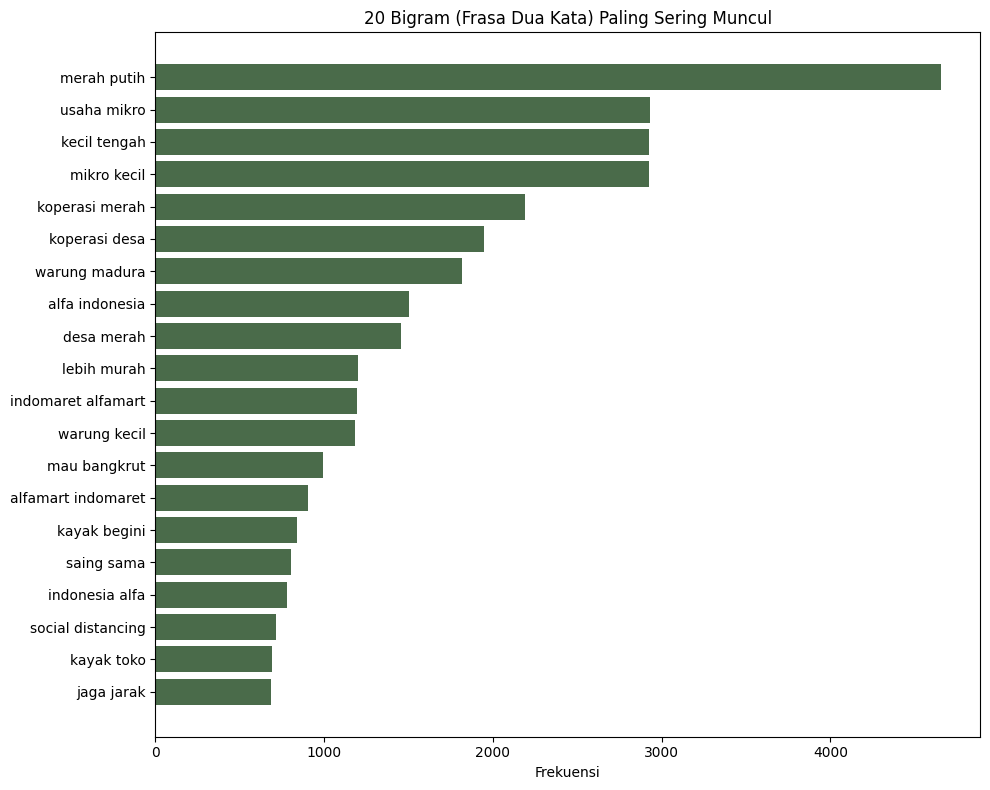

In [15]:
# -*- coding: utf-8 -*-
"""
TAHAP 14 - ANALISIS BIGRAM (FRASA DUA KATA)
==============================================
Frekuensi kata tunggal (tahap 13) kadang kurang menangkap konteks,
misalnya kata "harga" saja ambigu -- bisa "harga murah" atau "harga
mahal". Analisis bigram (pasangan dua kata berurutan) membantu melihat
frasa yang lebih bermakna dan sering muncul, sebagai bekal tambahan
sebelum topic modeling (LDA) pada Rumusan Masalah #2.

Input  : KDMP_clean_final.csv
Output : (dicetak ke konsol) + grafik05_top20_bigram.png
"""

from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

INPUT_PATH = "KDMP_clean_final.csv"

df = pd.read_csv(INPUT_PATH, keep_default_na=False, na_filter=False)


def get_bigrams(tokens: list) -> list:
    return [f"{tokens[i]} {tokens[i+1]}" for i in range(len(tokens) - 1)]


bigram_counter = Counter()
for text in df["final_text"]:
    tokens = text.split()
    bigram_counter.update(get_bigrams(tokens))

print(f"Total bigram unik: {len(bigram_counter)}")

print("\n20 bigram (frasa dua kata) paling sering muncul:")
top20 = bigram_counter.most_common(20)
for bigram, freq in top20:
    print(f"  {bigram:<30}: {freq}")

# --- Grafik ---
bigrams, freqs = zip(*top20)
plt.figure(figsize=(10, 8))
plt.barh(bigrams[::-1], freqs[::-1], color="#4A6B4A")
plt.xlabel("Frekuensi")
plt.title("20 Bigram (Frasa Dua Kata) Paling Sering Muncul")
plt.tight_layout()
plt.savefig("grafik05_top20_bigram.png", dpi=150)
print("\nGrafik disimpan: grafik05_top20_bigram.png")

Rentang tanggal data     : 2025-07-13 s.d. 2026-05-27
Rata-rata komentar/hari  : 771.2

10 hari dengan komentar terbanyak:
tanggal
2026-05-18    19970
2026-05-19    19757
2026-05-25    16158
2026-05-22    15351
2026-05-20    14643
2026-05-21    13325
2026-05-23     9488
2026-05-26     9106
2026-05-24     8003
2026-03-22     1924
dtype: int64

Grafik disimpan: grafik06_tren_volume_komentar.png


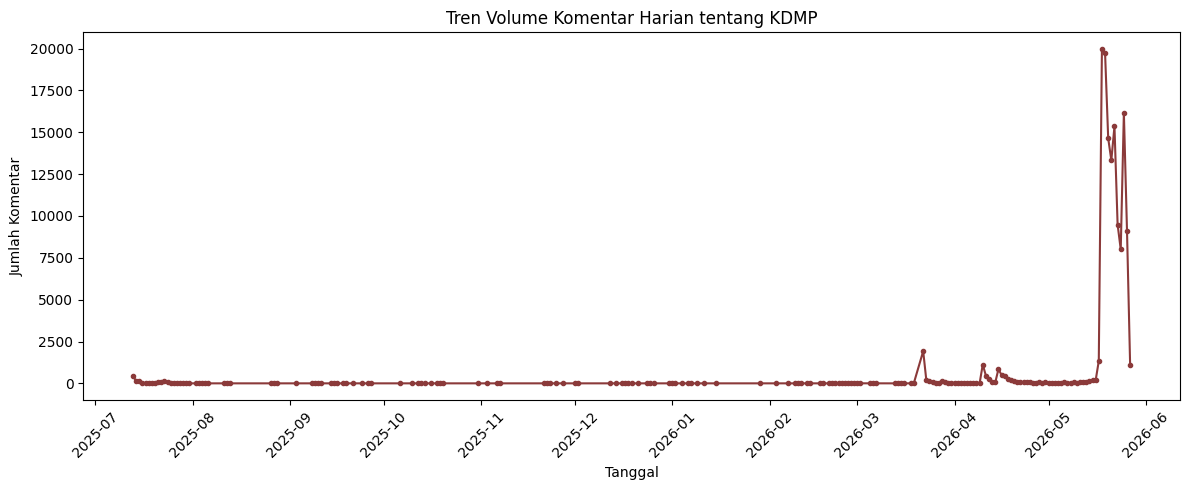

In [16]:
# -*- coding: utf-8 -*-
"""
TAHAP 15 - TREN VOLUME KOMENTAR TERHADAP WAKTU
================================================
Melihat bagaimana volume perbincangan netizen tentang KDMP berubah dari
waktu ke waktu (harian). Ini jadi dasar untuk tahap analisis sentimen
selanjutnya (Rumusan Masalah #3), karena nanti tren sentimen akan
dipetakan pada sumbu waktu yang sama.

Input  : KDMP_clean_final.csv
Output : (dicetak ke konsol) + grafik06_tren_volume_komentar.png
"""

import pandas as pd
import matplotlib.pyplot as plt

INPUT_PATH = "KDMP_clean_final.csv"

df = pd.read_csv(INPUT_PATH, keep_default_na=False, na_filter=False)

df["create_time"] = pd.to_datetime(df["create_time"], errors="coerce")
df = df.dropna(subset=["create_time"])

df["tanggal"] = df["create_time"].dt.date
harian = df.groupby("tanggal").size()

print("Rentang tanggal data     :", harian.index.min(), "s.d.", harian.index.max())
print("Rata-rata komentar/hari  :", round(harian.mean(), 1))
print("\n10 hari dengan komentar terbanyak:")
print(harian.sort_values(ascending=False).head(10))

# --- Grafik: tren volume komentar harian ---
plt.figure(figsize=(12, 5))
harian.plot(kind="line", marker="o", markersize=3, color="#8B3A3A")
plt.xlabel("Tanggal")
plt.ylabel("Jumlah Komentar")
plt.title("Tren Volume Komentar Harian tentang KDMP")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("grafik06_tren_volume_komentar.png", dpi=150)
print("\nGrafik disimpan: grafik06_tren_volume_komentar.png")

In [19]:
# -*- coding: utf-8 -*-
"""
TAHAP 16 - MEMBANGUN DICTIONARY & CORPUS (BAG-OF-WORDS) UNTUK LDA
====================================================================
LDA (Latent Dirichlet Allocation) butuh representasi dokumen sebagai
Bag-of-Words (BoW) -- BUKAN TF-IDF -- karena LDA adalah model generatif
probabilistik yang memodelkan frekuensi kemunculan kata mentah per topik,
sesuai kesepakatan awal (tidak menggunakan TF-IDF).

Langkah:
1. Load token hasil preprocessing (final_text -> list token)
2. Bangun Dictionary gensim (pemetaan kata <-> id)
3. Filter kata ekstrem: kata yang muncul di TERLALU SEDIKIT dokumen
   (kemungkinan typo/noise) atau TERLALU BANYAK dokumen (kata umum yang
   tidak membedakan topik)
4. Bangun corpus BoW (representasi tiap dokumen sebagai pasangan
   [(id_kata, frekuensi), ...])

Input  : KDMP_clean_final.csv
Output : dictionary_lda.dict, corpus_bow.pkl, tahap16_tokens.pkl
"""

!pip install gensim

import pickle
import pandas as pd
from gensim.corpora import Dictionary

INPUT_PATH = "KDMP_clean_final.csv"

df = pd.read_csv(INPUT_PATH, keep_default_na=False, na_filter=False)
tokens_list = df["final_text"].apply(lambda t: t.split()).tolist()

print(f"Total dokumen (komentar) : {len(tokens_list)}")

# 1. Bangun dictionary
dictionary = Dictionary(tokens_list)
print(f"Total kata unik sebelum filter : {len(dictionary)}")

# 2. Filter kata ekstrem
# no_below=10   -> buang kata yang muncul di kurang dari 10 dokumen (noise/typo)
# no_above=0.5  -> buang kata yang muncul di lebih dari 50% dokumen (terlalu umum)
# keep_n=None   -> tidak membatasi jumlah kata yang disimpan setelah filter
dictionary.filter_extremes(no_below=10, no_above=0.5, keep_n=None)
print(f"Total kata unik setelah filter  : {len(dictionary)}")

# 3. Bangun corpus BoW (bukan TF-IDF)
corpus_bow = [dictionary.doc2bow(tokens) for tokens in tokens_list]

# Buang dokumen yang jadi kosong setelah filter dictionary (tidak ada kata
# yang lolos filter no_below/no_above), karena tidak bisa dianalisis LDA
non_empty_idx = [i for i, bow in enumerate(corpus_bow) if len(bow) > 0]
print(f"Dokumen dibuang karena kosong setelah filter dictionary: "
      f"{len(corpus_bow) - len(non_empty_idx)}")

df_filtered = df.iloc[non_empty_idx].reset_index(drop=True)
corpus_bow_filtered = [corpus_bow[i] for i in non_empty_idx]
tokens_filtered = [tokens_list[i] for i in non_empty_idx]

print(f"Total dokumen final untuk LDA: {len(corpus_bow_filtered)}")

# --- Simpan hasil untuk tahap selanjutnya ---
dictionary.save("dictionary_lda.dict")
with open("corpus_bow.pkl", "wb") as f:
    pickle.dump(corpus_bow_filtered, f)
with open("tahap16_tokens.pkl", "wb") as f:
    pickle.dump(tokens_filtered, f)
df_filtered.to_csv("tahap16_data_filtered.csv", index=False, encoding="utf-8-sig")

print("\nTahap 16 selesai. File tersimpan:")
print("- dictionary_lda.dict")
print("- corpus_bow.pkl")
print("- tahap16_tokens.pkl")
print("- tahap16_data_filtered.csv")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 32.1 MB/s eta 0:00:00
Total dokumen (komentar) : 138817
Total kata unik sebelum filter : 32390
Total kata unik setelah filter  : 4331
Dokumen dibuang karena kosong setelah filter dictionary: 719
Total dokumen final untuk LDA: 138098

Tahap 16 selesai. File tersimpan:
- dictionary_lda.dict
- corpus_bow.pkl
- tahap16_tokens.pkl
- tahap16_data_filtered.csv


Menguji beberapa jumlah topik (proses ini cukup lama untuk data besar)...


  Jumlah topik =  3 -> coherence score = 0.4277


  Jumlah topik =  4 -> coherence score = 0.4940


  Jumlah topik =  5 -> coherence score = 0.4547
  Jumlah topik =  6 -> coherence score = 0.4068
  Jumlah topik =  7 -> coherence score = 0.4668
  Jumlah topik =  8 -> coherence score = 0.4487
  Jumlah topik =  9 -> coherence score = 0.4486
  Jumlah topik = 10 -> coherence score = 0.4523

Jumlah topik terbaik berdasarkan coherence score: 4 (coherence = 0.4940)
Grafik disimpan: grafik07_coherence_score.png

Jumlah topik terbaik disimpan ke k_topik_terbaik.txt untuk dipakai di tahap 18.


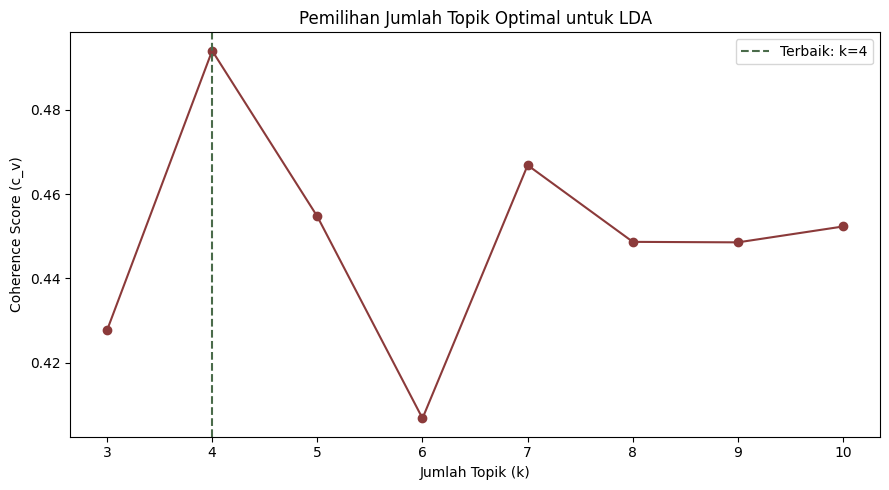

In [21]:
# -*- coding: utf-8 -*-
"""
TAHAP 17 - MENCARI JUMLAH TOPIK OPTIMAL (COHERENCE SCORE)
============================================================
LDA butuh ditentukan berapa jumlah topik (k) di awal. Menentukan k
sembarangan berisiko: kalau terlalu sedikit, topik jadi terlalu umum
dan campur aduk; kalau terlalu banyak, topik jadi terlalu spesifik dan
tumpang tindih maknanya.

Cara obyektif menentukan k adalah dengan COHERENCE SCORE (c_v): mengukur
seberapa "masuk akal" kata-kata dalam satu topik saling berkaitan secara
semantik. Semakin tinggi coherence score, semakin baik kualitas topik
yang dihasilkan.

Tahap ini mencoba beberapa nilai k (jumlah topik) dan memilih yang
coherence score-nya tertinggi.

Input  : dictionary_lda.dict, corpus_bow.pkl, tahap16_tokens.pkl
Output : grafik07_coherence_score.png + rekomendasi jumlah topik terbaik
"""

import pickle
import matplotlib.pyplot as plt
from gensim.corpora import Dictionary
from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel

dictionary = Dictionary.load("dictionary_lda.dict")
with open("corpus_bow.pkl", "rb") as f:
    corpus_bow = pickle.load(f)
with open("tahap16_tokens.pkl", "rb") as f:
    tokens_filtered = pickle.load(f)

# Rentang jumlah topik yang dicoba. Untuk data 220 ribu baris, rentang
# 3-10 topik biasanya cukup representatif untuk isu sebanyak ini; bisa
# diperluas kalau hasil topiknya masih terasa terlalu umum/campur.
RENTANG_K = range(3, 11)

hasil_coherence = []
print("Menguji beberapa jumlah topik (proses ini cukup lama untuk data besar)...")
for k in RENTANG_K:
    lda_model = LdaModel(
        corpus=corpus_bow,
        id2word=dictionary,
        num_topics=k,
        random_state=42,
        passes=10,
        iterations=100,
        alpha="auto",
        eta="auto",
    )
    coherence_model = CoherenceModel(
        model=lda_model, texts=tokens_filtered, dictionary=dictionary, coherence="c_v"
    )
    score = coherence_model.get_coherence()
    hasil_coherence.append((k, score))
    print(f"  Jumlah topik = {k:2d} -> coherence score = {score:.4f}")

k_terbaik, score_terbaik = max(hasil_coherence, key=lambda x: x[1])
print(f"\nJumlah topik terbaik berdasarkan coherence score: {k_terbaik} "
      f"(coherence = {score_terbaik:.4f})")

# --- Grafik coherence score per jumlah topik ---
ks, scores = zip(*hasil_coherence)
plt.figure(figsize=(9, 5))
plt.plot(ks, scores, marker="o", color="#8B3A3A")
plt.axvline(k_terbaik, color="#4A6B4A", linestyle="--", label=f"Terbaik: k={k_terbaik}")
plt.xlabel("Jumlah Topik (k)")
plt.ylabel("Coherence Score (c_v)")
plt.title("Pemilihan Jumlah Topik Optimal untuk LDA")
plt.xticks(list(ks))
plt.legend()
plt.tight_layout()
plt.savefig("grafik07_coherence_score.png", dpi=150)
print("Grafik disimpan: grafik07_coherence_score.png")

with open("k_topik_terbaik.txt", "w") as f:
    f.write(str(k_terbaik))
print(f"\nJumlah topik terbaik disimpan ke k_topik_terbaik.txt untuk dipakai di tahap 18.")

Melatih model LDA final dengan 4 topik...


Model tersimpan: model_lda_final.model

KATA KUNCI TIAP TOPIK (untuk diberi nama/label secara manual)

Topik 1: pak (0.050), kerja (0.031), kamu (0.025), simulator (0.023), tri (0.022), presiden (0.021), prabowo (0.020), menteri (0.019), bapak (0.019), penting (0.019)

Topik 2: apa (0.034), warung (0.031), kopdes (0.024), saing (0.023), koperasi (0.022), perintah (0.020), jadi (0.019), jual (0.017), negara (0.017), usaha (0.016)

Topik 3: sticker (0.042), banyak (0.027), lihat (0.023), program (0.021), semua (0.019), baru (0.018), korupsi (0.018), lama (0.016), berapa (0.015), uang (0.013)

Topik 4: kayak (0.041), tutup (0.030), mau (0.029), harga (0.028), beli (0.026), sama (0.025), indomaret (0.025), kalau (0.022), toko (0.020), kak (0.020)

Grafik disimpan: grafik08_topik_kata_kunci.png

CATATAN: beri nama/label pada tiap topik berdasarkan kata kuncinya di atas (mis. 'Topik 1: Persaingan dengan warung/UMKM') untuk laporan.


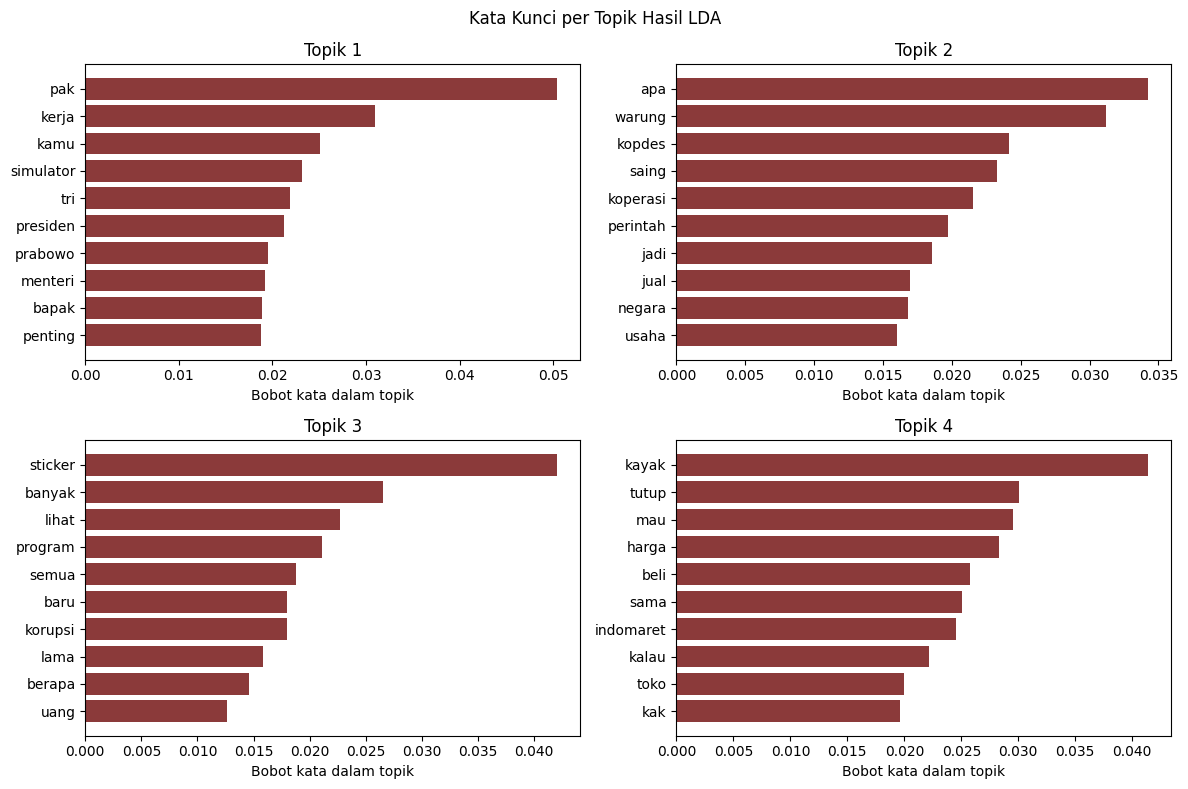

In [22]:
# -*- coding: utf-8 -*-
"""
TAHAP 18 - MELATIH MODEL LDA FINAL & INTERPRETASI TOPIK
==========================================================
Melatih ulang LDA dengan jumlah topik terbaik hasil tahap 17, lalu
menampilkan kata-kata kunci tiap topik untuk diberi LABEL/NAMA topik
secara manual (mis. "Persaingan dengan UMKM", "Transparansi Dana", dst).
Interpretasi nama topik perlu dilakukan manual dengan membaca kata-kata
kunci yang muncul -- ini bagian yang menjawab Rumusan Masalah #2.

Input  : dictionary_lda.dict, corpus_bow.pkl, k_topik_terbaik.txt
Output : model_lda_final.model + grafik08_topik_kata_kunci.png
"""

import pickle
import matplotlib.pyplot as plt
from gensim.corpora import Dictionary
from gensim.models import LdaModel

dictionary = Dictionary.load("dictionary_lda.dict")
with open("corpus_bow.pkl", "rb") as f:
    corpus_bow = pickle.load(f)

with open("k_topik_terbaik.txt") as f:
    K_TOPIK = int(f.read().strip())

print(f"Melatih model LDA final dengan {K_TOPIK} topik...")
lda_model = LdaModel(
    corpus=corpus_bow,
    id2word=dictionary,
    num_topics=K_TOPIK,
    random_state=42,
    passes=15,
    iterations=200,
    alpha="auto",
    eta="auto",
)
lda_model.save("model_lda_final.model")
print("Model tersimpan: model_lda_final.model")

print("\n" + "=" * 60)
print("KATA KUNCI TIAP TOPIK (untuk diberi nama/label secara manual)")
print("=" * 60)
N_KATA = 10
topik_kata_kunci = {}
for topic_id in range(K_TOPIK):
    kata_bobot = lda_model.show_topic(topic_id, topn=N_KATA)
    topik_kata_kunci[topic_id] = kata_bobot
    kata_list = ", ".join([f"{w} ({b:.3f})" for w, b in kata_bobot])
    print(f"\nTopik {topic_id + 1}: {kata_list}")

# --- Grafik: bar chart kata kunci tiap topik ---
n_cols = 2
n_rows = (K_TOPIK + 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for topic_id in range(K_TOPIK):
    kata_bobot = topik_kata_kunci[topic_id]
    kata, bobot = zip(*kata_bobot)
    axes[topic_id].barh(kata[::-1], bobot[::-1], color="#8B3A3A")
    axes[topic_id].set_title(f"Topik {topic_id + 1}")
    axes[topic_id].set_xlabel("Bobot kata dalam topik")

for ax in axes[K_TOPIK:]:
    ax.axis("off")

plt.suptitle("Kata Kunci per Topik Hasil LDA")
plt.tight_layout()
plt.savefig("grafik08_topik_kata_kunci.png", dpi=150)
print("\nGrafik disimpan: grafik08_topik_kata_kunci.png")

print("\nCATATAN: beri nama/label pada tiap topik berdasarkan kata kuncinya "
      "di atas (mis. 'Topik 1: Persaingan dengan warung/UMKM') untuk laporan.")

Hasil dengan label topik disimpan: KDMP_dengan_topik.csv

Distribusi jumlah komentar per topik:
  Topik 1: 4333 komentar (3.1%)
  Topik 2: 65184 komentar (47.2%)
  Topik 3: 22593 komentar (16.4%)
  Topik 4: 45988 komentar (33.3%)

Grafik disimpan: grafik09_distribusi_topik.png

CATATAN: gabungkan dengan nama/label topik dari tahap 18 saat menulis kesimpulan di laporan (mis. 'Topik 1 (Persaingan UMKM) paling banyak dibahas dengan X% dari seluruh komentar').


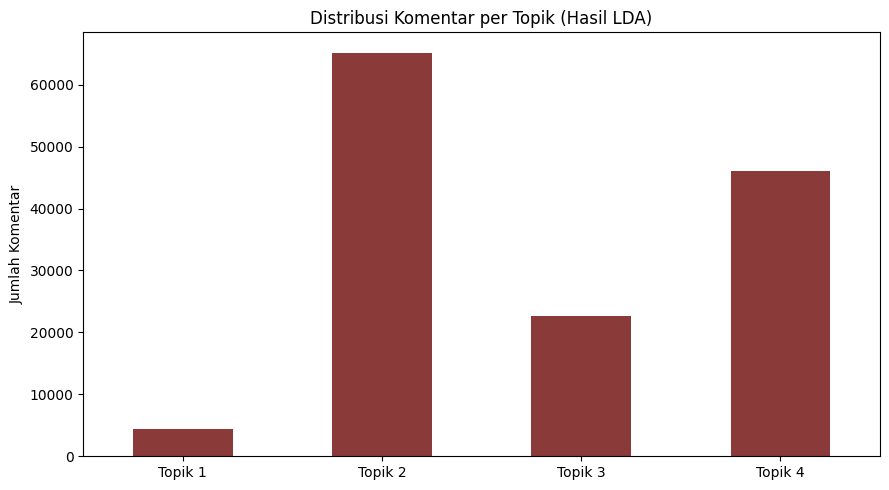

In [23]:
# -*- coding: utf-8 -*-
"""
TAHAP 19 - TOPIK DOMINAN PER KOMENTAR & DISTRIBUSI TOPIK
===========================================================
Setiap komentar diberi label "topik dominan" (topik dengan probabilitas
tertinggi menurut model LDA), lalu dihitung berapa banyak komentar yang
masuk ke tiap topik. Ini yang secara langsung menjawab Rumusan Masalah #2:
"topik/isu apa yang PALING SERING dikeluhkan/diapresiasi netizen".

Input  : tahap16_data_filtered.csv, model_lda_final.model, corpus_bow.pkl
Output : KDMP_dengan_topik.csv + grafik09_distribusi_topik.png
"""

import pickle
import pandas as pd
import matplotlib.pyplot as plt
from gensim.models import LdaModel

df = pd.read_csv("tahap16_data_filtered.csv", keep_default_na=False, na_filter=False)
with open("corpus_bow.pkl", "rb") as f:
    corpus_bow = pickle.load(f)
lda_model = LdaModel.load("model_lda_final.model")

# Tentukan topik dominan (probabilitas tertinggi) untuk tiap komentar
topik_dominan = []
probabilitas_dominan = []
for bow in corpus_bow:
    distribusi = lda_model.get_document_topics(bow)
    topik_id, prob = max(distribusi, key=lambda x: x[1])
    topik_dominan.append(topik_id + 1)  # +1 agar penomoran mulai dari Topik 1
    probabilitas_dominan.append(prob)

df["topik_dominan"] = topik_dominan
df["probabilitas_topik"] = probabilitas_dominan

df.to_csv("KDMP_dengan_topik.csv", index=False, encoding="utf-8-sig")
print("Hasil dengan label topik disimpan: KDMP_dengan_topik.csv")

print("\nDistribusi jumlah komentar per topik:")
distribusi_topik = df["topik_dominan"].value_counts().sort_index()
for topik, jumlah in distribusi_topik.items():
    persen = jumlah / len(df) * 100
    print(f"  Topik {topik}: {jumlah} komentar ({persen:.1f}%)")

# --- Grafik: distribusi jumlah komentar per topik ---
plt.figure(figsize=(9, 5))
distribusi_topik.index = [f"Topik {t}" for t in distribusi_topik.index]
distribusi_topik.plot(kind="bar", color="#8B3A3A")
plt.ylabel("Jumlah Komentar")
plt.title("Distribusi Komentar per Topik (Hasil LDA)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("grafik09_distribusi_topik.png", dpi=150)
print("\nGrafik disimpan: grafik09_distribusi_topik.png")

print("\nCATATAN: gabungkan dengan nama/label topik dari tahap 18 saat menulis "
      "kesimpulan di laporan (mis. 'Topik 1 (Persaingan UMKM) paling banyak "
      "dibahas dengan X% dari seluruh komentar').")

In [24]:
# -*- coding: utf-8 -*-
"""
TAHAP 20 - SENTIMENT SCORING (LEXICON-BASED)
================================================
Menjawab Rumusan Masalah #3: tren sentimen publik (positif/negatif/netral)
terhadap KDMP.

Metode: LEXICON-BASED, memakai InSet Lexicon.
Referensi:
- Koto, F., & Rahmaningtyas, G. Y. (2017). "InSet Lexicon: Evaluation of
  a Word List for Indonesian Sentiment Analysis in Microblogs". 2017
  International Conference on Asian Language Processing (IALP),
  Singapore: IEEE.
- Dataset: https://github.com/fajri91/InSet
- Berisi 3.609 kata positif dan 6.609 kata negatif, masing-masing punya
  bobot -5 s.d. +5 (dari yang paling negatif sampai paling positif).

Cara kerja:
1. Tiap kata di komentar (final_text) dicocokkan dengan lexicon.
2. Skor sentimen komentar = jumlah bobot semua kata yang cocok di lexicon.
3. Klasifikasi:
   - skor > 0   -> POSITIF
   - skor < 0   -> NEGATIF
   - skor == 0  -> NETRAL (termasuk komentar yang tidak ada kata
                   bermuatan sentimen sama sekali di lexicon)

Input  : KDMP_dengan_topik.csv (hasil tahap 19, sudah ada label topik),
         lexicon_sentimen.csv
Output : KDMP_dengan_sentimen.csv
"""

import pandas as pd

INPUT_PATH = "KDMP_dengan_topik.csv"
LEXICON_PATH = "lexicon_sentimen.csv"
OUTPUT_PATH = "KDMP_dengan_sentimen.csv"

# --- Load lexicon sebagai dictionary lookup ---
lexicon_df = pd.read_csv(LEXICON_PATH)
LEXICON = dict(zip(lexicon_df["word"], lexicon_df["weight"]))
print(f"Total entri lexicon dimuat: {len(LEXICON)} kata "
      f"({(lexicon_df['weight']>0).sum()} positif, {(lexicon_df['weight']<0).sum()} negatif)")


def hitung_skor_sentimen(text: str) -> int:
    """Menjumlahkan bobot semua kata dalam teks yang cocok dengan lexicon."""
    tokens = text.split()
    return sum(LEXICON.get(t, 0) for t in tokens)


def klasifikasi_sentimen(skor: int) -> str:
    if skor > 0:
        return "positif"
    elif skor < 0:
        return "negatif"
    else:
        return "netral"


df = pd.read_csv(INPUT_PATH, keep_default_na=False, na_filter=False)

print("Menghitung skor sentimen tiap komentar...")
df["skor_sentimen"] = df["final_text"].apply(hitung_skor_sentimen)
df["label_sentimen"] = df["skor_sentimen"].apply(klasifikasi_sentimen)

df.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")
print(f"Tahap 20 selesai -> disimpan ke {OUTPUT_PATH}")

print("\nDistribusi label sentimen:")
print(df["label_sentimen"].value_counts())

print("\nContoh hasil (5 baris pertama):")
print(df[["comment", "final_text", "skor_sentimen", "label_sentimen"]].head())

Total entri lexicon dimuat: 9074 kata (3609 positif, 6609 negatif)


/tmp/ipykernel_1990/450936396.py:60: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(INPUT_PATH, keep_default_na=False, na_filter=False)


Menghitung skor sentimen tiap komentar...
Tahap 20 selesai -> disimpan ke KDMP_dengan_sentimen.csv

Distribusi label sentimen:
label_sentimen
negatif    99644
netral     20499
positif    17955
Name: count, dtype: int64

Contoh hasil (5 baris pertama):
                                             comment  \
0                     Beliau bilang untung nya 2 m ?   
1                                        Makasih Mas   
2  Gimana untung nya 2 m..barang yg di jual ajh g...   
3         [Sticker] dibilang Makasih Mas udah 2M itu   
4  Kalo niat membantu UMKM, harusnya koprasi mera...   

                                          final_text  skor_sentimen  \
0                          beliau bilang untung sama              2   
1                                   terima kasih mas              1   
2             bagaimana untung sama barang jual sama              6   
3               sticker bilang terima kasih mas sama              4   
4  kalau niat bantu usaha mikro kecil tengah haru...    

/tmp/ipykernel_1990/2955631242.py:15: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("KDMP_dengan_sentimen.csv", keep_default_na=False, na_filter=False)


Distribusi sentimen keseluruhan terhadap KDMP:
  Positif   : 17955 komentar (13.0%)
  Netral    : 20499 komentar (14.8%)
  Negatif   : 99644 komentar (72.2%)

Grafik disimpan: grafik10_distribusi_sentimen.png


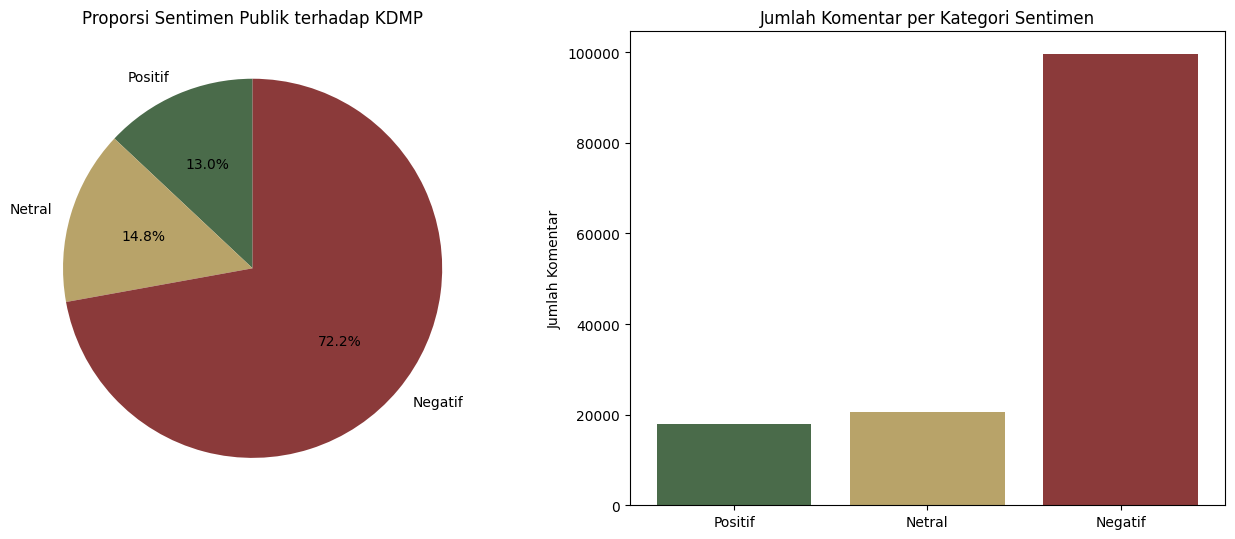

In [25]:
# -*- coding: utf-8 -*-
"""
TAHAP 21 - DISTRIBUSI SENTIMEN KESELURUHAN
=============================================
Melihat proporsi sentimen positif/negatif/netral secara keseluruhan
terhadap KDMP -- jawaban langsung untuk bagian pertama Rumusan Masalah #3.

Input  : KDMP_dengan_sentimen.csv
Output : (dicetak ke konsol) + grafik10_distribusi_sentimen.png
"""

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("KDMP_dengan_sentimen.csv", keep_default_na=False, na_filter=False)

distribusi = df["label_sentimen"].value_counts()
urutan = ["positif", "netral", "negatif"]
distribusi = distribusi.reindex(urutan).fillna(0)

print("Distribusi sentimen keseluruhan terhadap KDMP:")
for label, jumlah in distribusi.items():
    persen = jumlah / len(df) * 100
    print(f"  {label.capitalize():<10}: {int(jumlah)} komentar ({persen:.1f}%)")

warna = {"positif": "#4A6B4A", "netral": "#B8A369", "negatif": "#8B3A3A"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Pie chart
axes[0].pie(
    distribusi.values,
    labels=[l.capitalize() for l in distribusi.index],
    autopct="%1.1f%%",
    colors=[warna[l] for l in distribusi.index],
    startangle=90,
)
axes[0].set_title("Proporsi Sentimen Publik terhadap KDMP")

# Bar chart
axes[1].bar(
    [l.capitalize() for l in distribusi.index],
    distribusi.values,
    color=[warna[l] for l in distribusi.index],
)
axes[1].set_ylabel("Jumlah Komentar")
axes[1].set_title("Jumlah Komentar per Kategori Sentimen")

plt.tight_layout()
plt.savefig("grafik10_distribusi_sentimen.png", dpi=150)
print("\nGrafik disimpan: grafik10_distribusi_sentimen.png")

/tmp/ipykernel_1990/3807429068.py:16: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("KDMP_dengan_sentimen.csv", keep_default_na=False, na_filter=False)


Tren sentimen harian (5 hari pertama):
label_sentimen  positif  netral  negatif
tanggal                                 
2025-07-13           63      67      310
2025-07-14           18      22       94
2025-07-15           26      27      116
2025-07-16            8       2       22
2025-07-17            1       8       17

Grafik disimpan: grafik11_tren_sentimen_waktu.png


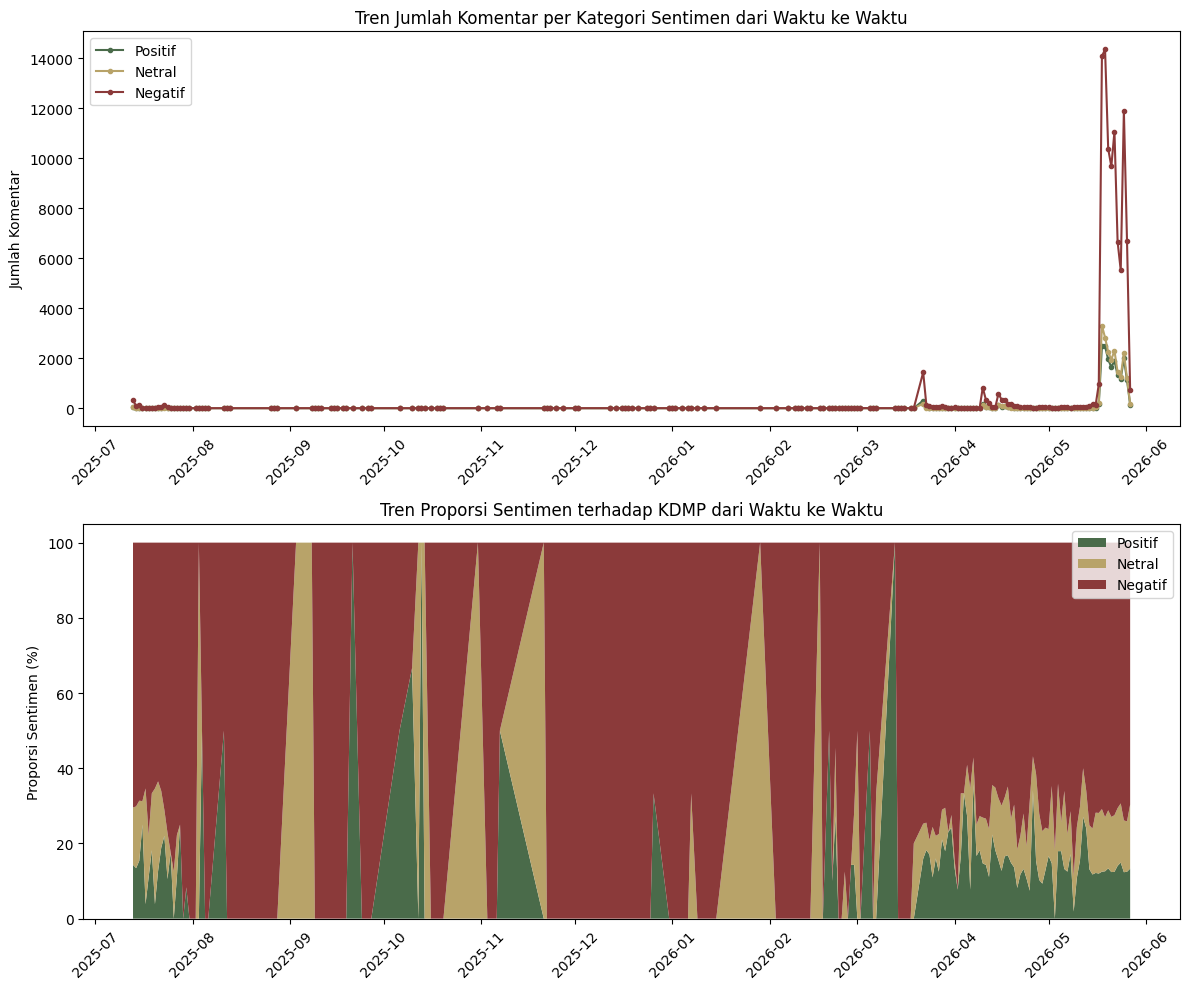

In [26]:
# -*- coding: utf-8 -*-
"""
TAHAP 22 - TREN SENTIMEN TERHADAP WAKTU
==========================================
Melihat bagaimana proporsi sentimen positif/negatif/netral berubah dari
waktu ke waktu -- jawaban bagian kedua Rumusan Masalah #3 ("tren
sentimen publik"), melengkapi tren volume komentar dari tahap 15.

Input  : KDMP_dengan_sentimen.csv
Output : (dicetak ke konsol) + grafik11_tren_sentimen_waktu.png
"""

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("KDMP_dengan_sentimen.csv", keep_default_na=False, na_filter=False)
df["create_time"] = pd.to_datetime(df["create_time"], errors="coerce")
df = df.dropna(subset=["create_time"])

df["tanggal"] = df["create_time"].dt.date

# Hitung jumlah komentar per kategori sentimen per tanggal
tren = df.groupby(["tanggal", "label_sentimen"]).size().unstack(fill_value=0)
for kolom in ["positif", "netral", "negatif"]:
    if kolom not in tren.columns:
        tren[kolom] = 0
tren = tren[["positif", "netral", "negatif"]]

print("Tren sentimen harian (5 hari pertama):")
print(tren.head())

# --- Grafik 1: tren jumlah komentar per kategori sentimen (garis) ---
warna = {"positif": "#4A6B4A", "netral": "#B8A369", "negatif": "#8B3A3A"}
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

for kolom in ["positif", "netral", "negatif"]:
    axes[0].plot(tren.index, tren[kolom], label=kolom.capitalize(), color=warna[kolom], marker="o", markersize=3)
axes[0].set_ylabel("Jumlah Komentar")
axes[0].set_title("Tren Jumlah Komentar per Kategori Sentimen dari Waktu ke Waktu")
axes[0].legend()
axes[0].tick_params(axis="x", rotation=45)

# --- Grafik 2: tren proporsi (persentase) sentimen, lebih menonjolkan pergeseran opini ---
tren_persen = tren.div(tren.sum(axis=1), axis=0) * 100
axes[1].stackplot(
    tren_persen.index,
    tren_persen["positif"],
    tren_persen["netral"],
    tren_persen["negatif"],
    labels=["Positif", "Netral", "Negatif"],
    colors=[warna["positif"], warna["netral"], warna["negatif"]],
)
axes[1].set_ylabel("Proporsi Sentimen (%)")
axes[1].set_title("Tren Proporsi Sentimen terhadap KDMP dari Waktu ke Waktu")
axes[1].legend(loc="upper right")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("grafik11_tren_sentimen_waktu.png", dpi=150)
print("\nGrafik disimpan: grafik11_tren_sentimen_waktu.png")

/tmp/ipykernel_1990/1310622513.py:19: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("KDMP_dengan_sentimen.csv", keep_default_na=False, na_filter=False)


Tabel silang topik x sentimen (jumlah komentar):
label_sentimen  positif  netral  negatif
topik_dominan                           
1                   868    1008     2457
2                  7741    8545    48898
3                  2907    3864    15822
4                  6439    7082    32467

Proporsi sentimen per topik (%):
label_sentimen  positif  netral  negatif
topik_dominan                           
1                  20.0    23.3     56.7
2                  11.9    13.1     75.0
3                  12.9    17.1     70.0
4                  14.0    15.4     70.6

Topik dengan proporsi NEGATIF tertinggi : Topik 2 (75.0%)
Topik dengan proporsi POSITIF tertinggi  : Topik 1 (20.0%)

Grafik disimpan: grafik12_sentimen_per_topik.png

CATATAN: gunakan hasil ini bersama label/nama topik dari tahap 18 untuk menyusun kesimpulan akhir laporan, mis. 'Topik mengenai X paling banyak menerima sentimen negatif, sementara topik Y paling diapresiasi'.


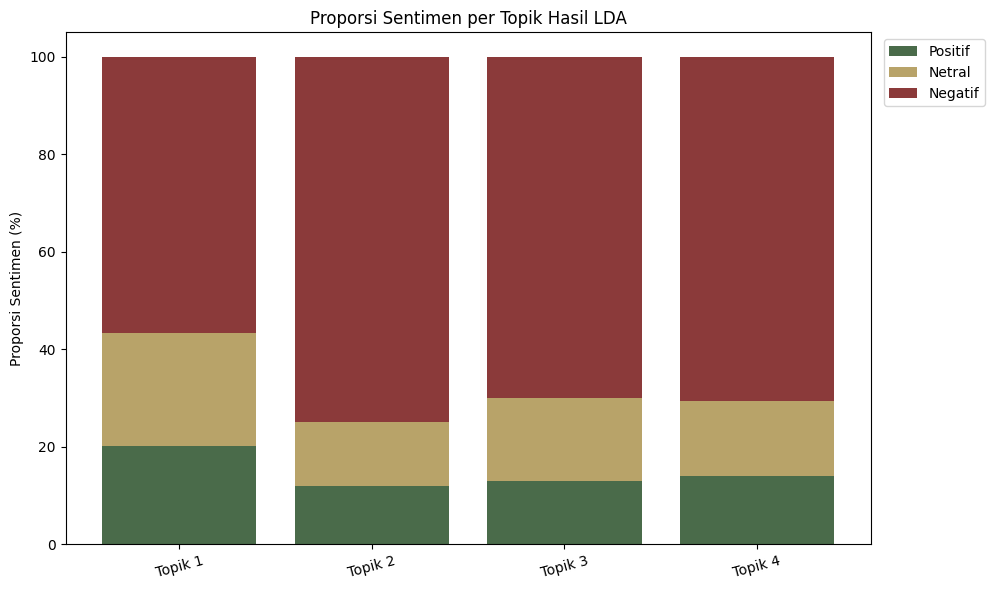

In [27]:
# -*- coding: utf-8 -*-
"""
TAHAP 23 - SENTIMEN PER TOPIK
================================
Menggabungkan hasil topic modeling (tahap 16-19) dengan sentiment
analysis (tahap 20-22): topik mana yang paling banyak dikomentari
secara POSITIF, dan topik mana yang paling banyak dikomentari secara
NEGATIF. Ini jawaban paling lengkap yang bisa dipakai untuk kesimpulan
akhir laporan, menyatukan Rumusan Masalah #2 dan #3 sekaligus.

Input  : KDMP_dengan_sentimen.csv (sudah punya kolom topik_dominan &
         label_sentimen dari tahap sebelumnya)
Output : (dicetak ke konsol) + grafik12_sentimen_per_topik.png
"""

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("KDMP_dengan_sentimen.csv", keep_default_na=False, na_filter=False)

# Tabel silang: jumlah komentar per topik x kategori sentimen
tabel_silang = pd.crosstab(df["topik_dominan"], df["label_sentimen"])
for kolom in ["positif", "netral", "negatif"]:
    if kolom not in tabel_silang.columns:
        tabel_silang[kolom] = 0
tabel_silang = tabel_silang[["positif", "netral", "negatif"]]

print("Tabel silang topik x sentimen (jumlah komentar):")
print(tabel_silang)

# Proporsi per topik (dalam %), memudahkan melihat topik mana yang
# paling didominasi sentimen negatif/positif secara relatif
proporsi = tabel_silang.div(tabel_silang.sum(axis=1), axis=0) * 100
print("\nProporsi sentimen per topik (%):")
print(proporsi.round(1))

topik_paling_negatif = proporsi["negatif"].idxmax()
topik_paling_positif = proporsi["positif"].idxmax()
print(f"\nTopik dengan proporsi NEGATIF tertinggi : Topik {topik_paling_negatif} "
      f"({proporsi.loc[topik_paling_negatif, 'negatif']:.1f}%)")
print(f"Topik dengan proporsi POSITIF tertinggi  : Topik {topik_paling_positif} "
      f"({proporsi.loc[topik_paling_positif, 'positif']:.1f}%)")

# --- Grafik: stacked bar chart proporsi sentimen per topik ---
warna = {"positif": "#4A6B4A", "netral": "#B8A369", "negatif": "#8B3A3A"}
proporsi.index = [f"Topik {t}" for t in proporsi.index]

fig, ax = plt.subplots(figsize=(10, 6))
bottom = None
for kolom in ["positif", "netral", "negatif"]:
    ax.bar(proporsi.index, proporsi[kolom], bottom=bottom, label=kolom.capitalize(), color=warna[kolom])
    bottom = proporsi[kolom] if bottom is None else bottom + proporsi[kolom]

ax.set_ylabel("Proporsi Sentimen (%)")
ax.set_title("Proporsi Sentimen per Topik Hasil LDA")
ax.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("grafik12_sentimen_per_topik.png", dpi=150)
print("\nGrafik disimpan: grafik12_sentimen_per_topik.png")

print("\nCATATAN: gunakan hasil ini bersama label/nama topik dari tahap 18 "
      "untuk menyusun kesimpulan akhir laporan, mis. 'Topik mengenai X paling "
      "banyak menerima sentimen negatif, sementara topik Y paling diapresiasi'.")